<a href="https://colab.research.google.com/github/njwbilll/Tugas-5_Grokking-Deep-Learning-MANNING_Najwa-Bilqis-Al-Khalidah/blob/main/11_Neural_Networks_That_Understand_Language.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Chapter 11: Neural Networks that Understand Language

## King − Man + Woman = ?

Reproduksi dan pendalaman teori Chapter 11 dari buku *Grokking Deep Learning*.

Bab ini memperkenalkan bagaimana neural network dapat merepresentasikan kata sebagai vektor numerik sehingga hubungan semantik antar kata dapat dipelajari secara otomatis.



# Learning Objectives

Setelah mempelajari bab ini, mahasiswa mampu:

1. Memahami representasi numerik kata.
2. Memahami One Hot Encoding.
3. Memahami keterbatasan One Hot Encoding.
4. Memahami Word Embedding.
5. Memahami ruang vektor semantik.
6. Memahami Cosine Similarity.
7. Memahami hubungan kata menggunakan embedding.
8. Mengimplementasikan word embedding sederhana menggunakan NumPy.
9. Memahami analogi vektor seperti King − Man + Woman.
10. Menghubungkan konsep embedding dengan NLP modern.



# Mengapa Bahasa Sulit Dipahami Komputer

Komputer hanya memahami angka.

Kalimat:

`The king rules the kingdom`

harus diubah menjadi representasi numerik sebelum diproses oleh neural network.

Tantangan utama adalah bagaimana mengubah kata menjadi angka tanpa kehilangan makna.



# One Hot Encoding

Salah satu metode paling sederhana adalah One Hot Encoding.

Misalkan vocabulary:

* king
* queen
* man
* woman

Representasinya:

king = [1,0,0,0]

queen = [0,1,0,0]

man = [0,0,1,0]

woman = [0,0,0,1]


In [1]:

import numpy as np

vocab = ["king","queen","man","woman"]

one_hot = np.eye(len(vocab))

for word, vec in zip(vocab, one_hot):
    print(word, vec)


king [1. 0. 0. 0.]
queen [0. 1. 0. 0.]
man [0. 0. 1. 0.]
woman [0. 0. 0. 1.]



# Kelemahan One Hot Encoding

One Hot Encoding tidak menyimpan informasi hubungan antar kata.

Contoh:

* king dan queen memiliki hubungan yang kuat.
* king dan apple tidak memiliki hubungan kuat.

Namun pada One Hot Encoding seluruh kata saling ortogonal sehingga tidak ada informasi semantik yang tersimpan.



# Word Embedding

Word Embedding mengubah kata menjadi vektor padat berdimensi lebih kecil.

Contoh:

king = [0.81, 0.75, 0.20]

queen = [0.79, 0.82, 0.22]

Vektor yang mirip menunjukkan makna yang mirip.


In [2]:

embeddings = {
    "king": np.array([0.80,0.75,0.20]),
    "queen": np.array([0.78,0.83,0.21]),
    "man": np.array([0.70,0.20,0.10]),
    "woman": np.array([0.68,0.28,0.11])
}

for word, vector in embeddings.items():
    print(word, vector)


king [0.8  0.75 0.2 ]
queen [0.78 0.83 0.21]
man [0.7 0.2 0.1]
woman [0.68 0.28 0.11]



# Ruang Vektor Semantik

Dalam embedding space, kata dengan makna mirip cenderung berada berdekatan.

Contoh:

* king dekat dengan queen
* prince dekat dengan princess
* cat dekat dengan kitten

Neural network mempelajari posisi ini selama proses training.



# Dot Product Review

Dot product mengukur tingkat kesamaan dua vektor.

Semakin besar nilainya, semakin mirip kedua vektor.


In [3]:

king = embeddings["king"]
queen = embeddings["queen"]

similarity = np.dot(king, queen)

print(similarity)


1.2885000000000002



# Cosine Similarity

Cosine Similarity lebih umum digunakan dalam NLP karena tidak terlalu dipengaruhi panjang vektor.


In [4]:

def cosine_similarity(a,b):

    return np.dot(a,b) / (
        np.linalg.norm(a) *
        np.linalg.norm(b)
    )

print(
    cosine_similarity(
        embeddings["king"],
        embeddings["queen"]
    )
)


0.9980609716234113



# Embedding Matrix

Dalam neural network, seluruh embedding disimpan dalam sebuah matriks.

Setiap baris mewakili satu kata.


In [5]:

embedding_matrix = np.array([
    embeddings["king"],
    embeddings["queen"],
    embeddings["man"],
    embeddings["woman"]
])

print(embedding_matrix)
print(embedding_matrix.shape)


[[0.8  0.75 0.2 ]
 [0.78 0.83 0.21]
 [0.7  0.2  0.1 ]
 [0.68 0.28 0.11]]
(4, 3)



# Mengambil Embedding Berdasarkan Index

Neural network biasanya bekerja menggunakan index kata.


In [6]:

word_to_index = {
    "king":0,
    "queen":1,
    "man":2,
    "woman":3
}

index = word_to_index["king"]

print(embedding_matrix[index])


[0.8  0.75 0.2 ]



# Hubungan Semantik Antar Kata

Ide utama chapter ini adalah bahwa operasi matematika pada embedding dapat menghasilkan hubungan linguistik yang bermakna.


In [7]:

king = np.array([0.80,0.75,0.20])
man = np.array([0.70,0.20,0.10])
woman = np.array([0.68,0.28,0.11])

result = king - man + woman

print(result)


[0.78 0.83 0.21]



# King Minus Man Plus Woman

Dalam embedding yang dilatih dengan baik:

King − Man + Woman ≈ Queen

Hal ini terjadi karena embedding berhasil mempelajari konsep:

* gender
* kerajaan
* hubungan semantik

secara otomatis dari data.


In [8]:

embeddings = {
    "king": np.array([0.80,0.75,0.20]),
    "queen": np.array([0.78,0.83,0.21]),
    "man": np.array([0.70,0.20,0.10]),
    "woman": np.array([0.68,0.28,0.11])
}

query = embeddings["king"] - embeddings["man"] + embeddings["woman"]

def closest_word(query, embeddings):

    best_word = None
    best_score = -1

    for word, vector in embeddings.items():

        score = cosine_similarity(query, vector)

        if score > best_score:
            best_score = score
            best_word = word

    return best_word, best_score

print(closest_word(query, embeddings))


('queen', np.float64(1.0000000000000002))



# Membangun Vocabulary dari Nol

Langkah pertama NLP adalah membangun vocabulary.


In [9]:

corpus = [
    "king rules kingdom",
    "queen rules kingdom",
    "man works",
    "woman works"
]

vocab = sorted(
    list(
        set(
            " ".join(corpus).split()
        )
    )
)

print(vocab)


['king', 'kingdom', 'man', 'queen', 'rules', 'woman', 'works']



# Membuat One Hot Encoder dari Nol


In [10]:

vocab_size = len(vocab)

word_to_index = {
    word:i
    for i, word in enumerate(vocab)
}

def one_hot_encode(word):

    vector = np.zeros(vocab_size)

    vector[word_to_index[word]] = 1

    return vector

print(one_hot_encode("king"))


[1. 0. 0. 0. 0. 0. 0.]



# Embedding Layer Sederhana Menggunakan NumPy


In [11]:

embedding_dim = 5

embedding_matrix = np.random.randn(
    vocab_size,
    embedding_dim
)

embedding_matrix


array([[ 1.20688921, -1.15248195,  0.28403879,  0.2829381 ,  1.30403826],
       [-1.45063208, -0.73464721,  0.15979035, -0.70221218,  1.34697702],
       [-0.86046424, -0.92179826,  0.77133503,  1.69675175, -0.70716792],
       [-0.81657025, -0.31971862,  2.13644974, -0.94413511,  0.93042468],
       [-0.57759292, -1.09404104,  0.64273006,  0.42354474,  1.00475563],
       [-0.29172018,  0.5563202 , -0.15931436, -0.30140777, -0.8571751 ],
       [-1.75079113,  1.64208258, -0.94732696, -0.19102168, -0.09863744]])

In [12]:

word = "king"

index = word_to_index[word]

embedding_vector = embedding_matrix[index]

print(embedding_vector)


[ 1.20688921 -1.15248195  0.28403879  0.2829381   1.30403826]



# Similarity Search

Mencari kata yang paling mirip dengan suatu kata.


In [13]:

def most_similar(word):

    idx = word_to_index[word]

    target = embedding_matrix[idx]

    scores = []

    for other_word in vocab:

        other_idx = word_to_index[other_word]

        score = cosine_similarity(
            target,
            embedding_matrix[other_idx]
        )

        scores.append((other_word, score))

    scores.sort(
        key=lambda x:x[1],
        reverse=True
    )

    return scores[:5]

print(most_similar("king"))


[('king', np.float64(0.9999999999999998)), ('rules', np.float64(0.5704909568011406)), ('queen', np.float64(0.16307325414377094)), ('kingdom', np.float64(0.14538879349713338)), ('man', np.float64(-0.03916652209629276))]



# Visualisasi Embedding Space


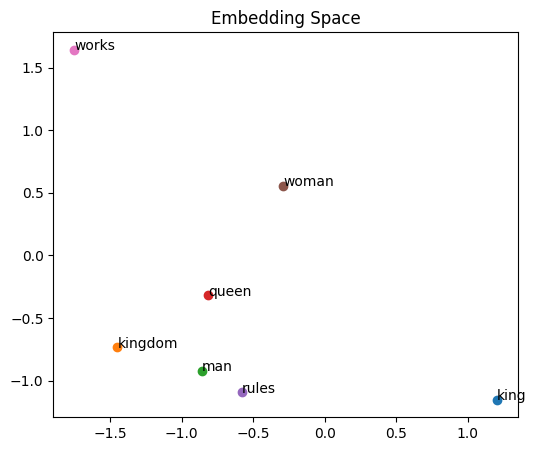

In [14]:

import matplotlib.pyplot as plt

points = embedding_matrix[:, :2]

plt.figure(figsize=(6,5))

for i, word in enumerate(vocab):

    plt.scatter(
        points[i,0],
        points[i,1]
    )

    plt.text(
        points[i,0],
        points[i,1],
        word
    )

plt.title("Embedding Space")
plt.show()



# Bagaimana Embedding Dipelajari

Neural network tidak diberi tahu arti kata secara eksplisit.

Model hanya melihat konteks penggunaan kata.

Melalui proses optimisasi dan backpropagation, kata yang sering muncul pada konteks serupa akan memiliki representasi yang mirip.



# Continuous Bag of Words

CBOW memprediksi kata target berdasarkan kata di sekitarnya.

Contoh:

Input:
the king ____ the kingdom

Target:
rules



# Skip Gram

Skip Gram melakukan kebalikan dari CBOW.

Input:
king

Target:
kata kata yang muncul di sekitar king.



# Hubungan dengan Word2Vec

Word2Vec menggunakan ide embedding untuk mempelajari hubungan semantik secara otomatis.

Dua arsitektur utama:

1. CBOW
2. Skip Gram



# Hubungan dengan NLP Modern

Konsep embedding menjadi fondasi:

* Word2Vec
* GloVe
* FastText
* ELMo
* BERT
* GPT

Walaupun model modern jauh lebih kompleks, prinsip dasar representasi vektor kata tetap digunakan.



# Kelebihan Word Embedding

1. Dimensi lebih kecil.
2. Menyimpan informasi semantik.
3. Dapat melakukan similarity search.
4. Mendukung reasoning sederhana.
5. Menjadi fondasi NLP modern.



# Keterbatasan Word Embedding

1. Satu kata memiliki satu representasi tetap.
2. Sulit menangani makna ganda.
3. Sensitif terhadap data pelatihan.
4. Tidak mempertimbangkan konteks secara penuh.



# Latihan

1. Implementasikan cosine similarity tanpa NumPy.
2. Tambahkan kata prince dan princess.
3. Uji analogi:

Prince − Man + Woman

4. Visualisasikan embedding menggunakan PCA.
5. Bandingkan dot product dan cosine similarity.



# Kesimpulan

Pada chapter ini kita mempelajari:

1. One Hot Encoding.
2. Word Embedding.
3. Embedding Matrix.
4. Dot Product.
5. Cosine Similarity.
6. Semantic Space.
7. Similarity Search.
8. King − Man + Woman ≈ Queen.
9. Implementasi NumPy dari nol.
10. Hubungan embedding dengan NLP modern.

Konsep word embedding merupakan salah satu terobosan penting dalam deep learning karena memungkinkan neural network memahami hubungan semantik antar kata melalui representasi vektor.
